# Unit 2 — Frequency Domain Analysis (DFT / FFT)

**Syllabus coverage:** Unit 2 — Frequency Domain Operations (DFT)

**Experiment covered:** #4 (Power Spectral Density)

We apply the FFT and PSD estimation to the entropy signal to identify periodicities
and test for 1/f (pink noise) behaviour indicating long-range dependence.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import signal as sp_signal
from scipy import stats

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

REPO_ROOT = Path('.').resolve().parent
DATA_DIR = REPO_ROOT / 'data' / 'processed'
FIG_DIR = REPO_ROOT / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
SAVEKW = dict(dpi=150, bbox_inches='tight')

## Section 1 — FFT of Entropy Signal

Signal length N = 6759


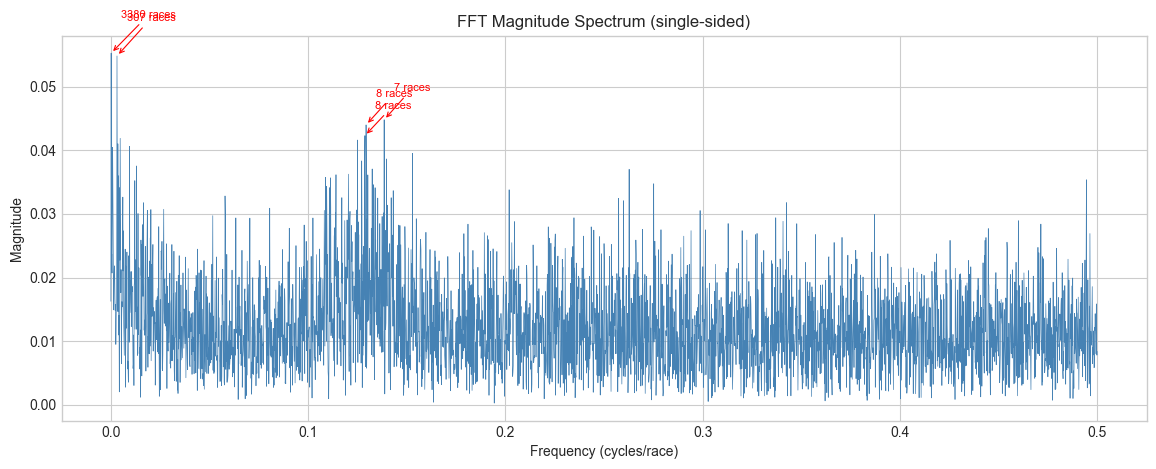

Top 5 dominant frequencies:
  f=0.000296 cycles/race, period=3379.5 races, magnitude=0.0552
  f=0.003255 cycles/race, period=307.2 races, magnitude=0.0548
  f=0.138630 cycles/race, period=7.2 races, magnitude=0.0448
  f=0.129457 cycles/race, period=7.7 races, magnitude=0.0440
  f=0.128865 cycles/race, period=7.8 races, magnitude=0.0423


In [2]:
df = pd.read_csv(DATA_DIR / 'entropy_signal.csv', parse_dates=['meet_date'])
H = df['entropy_H'].dropna().values
N = len(H)
print(f'Signal length N = {N}')

# Compute FFT
H_fft = np.fft.fft(H)
freqs = np.fft.fftfreq(N)

# Single-sided spectrum
pos_mask = freqs > 0
freqs_pos = freqs[pos_mask]
magnitude = np.abs(H_fft[pos_mask]) * 2 / N

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(freqs_pos, magnitude, lw=0.5, color='steelblue')
ax.set_xlabel('Frequency (cycles/race)')
ax.set_ylabel('Magnitude')
ax.set_title('FFT Magnitude Spectrum (single-sided)')

# Annotate top 5 peaks
peak_idx = np.argsort(magnitude)[-5:]
for i in peak_idx:
    period = 1 / freqs_pos[i]
    ax.annotate(f'{period:.0f} races',
                xy=(freqs_pos[i], magnitude[i]),
                xytext=(freqs_pos[i] + 0.005, magnitude[i] * 1.1),
                fontsize=8, color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

fig.savefig(FIG_DIR / 'unit2_fft_magnitude.png', **SAVEKW)
plt.show()

print('Top 5 dominant frequencies:')
for i in np.argsort(magnitude)[-5:][::-1]:
    print(f'  f={freqs_pos[i]:.6f} cycles/race, period={1/freqs_pos[i]:.1f} races, magnitude={magnitude[i]:.4f}')

## Section 2 — Power Spectral Density (Experiment #4)

We estimate PSD using Welch's method and the periodogram, then test for 1/f behaviour.

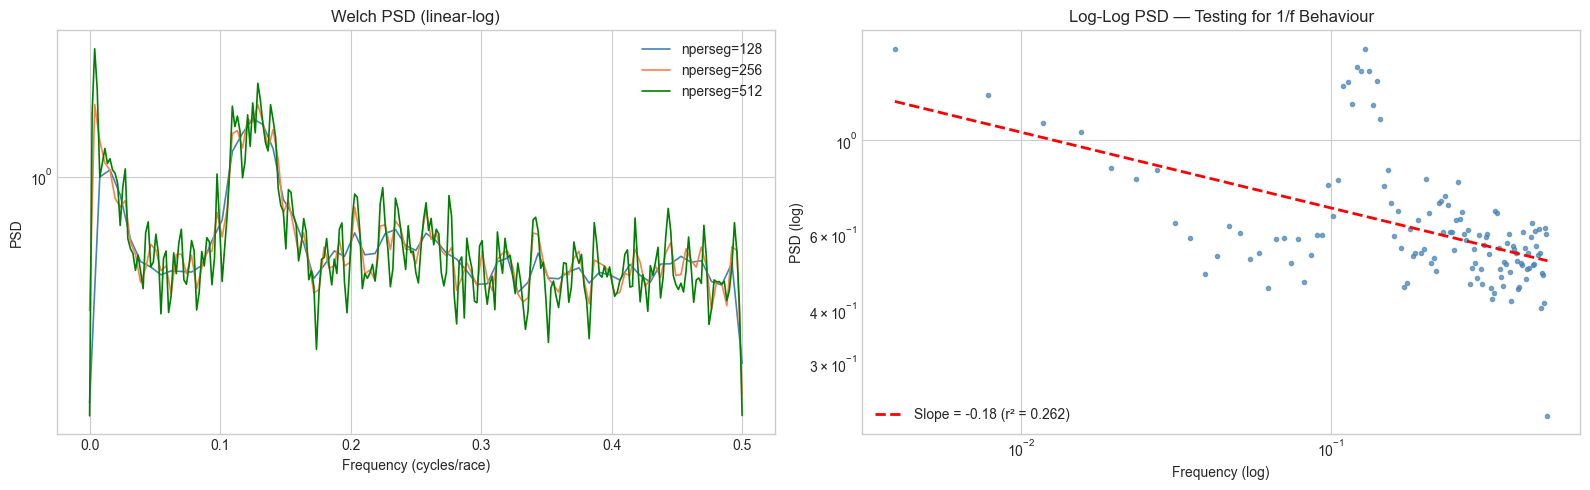

PSD log-log slope: -0.177
Slope = -0.177, not close to −1 → not classic 1/f noise


In [3]:
# Welch PSD with various window sizes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for nperseg, color, label in [(128, 'steelblue', 'nperseg=128'),
                               (256, 'coral', 'nperseg=256'),
                               (512, 'green', 'nperseg=512')]:
    f_welch, psd_welch = sp_signal.welch(H, fs=1.0, nperseg=nperseg)
    axes[0].semilogy(f_welch, psd_welch, lw=1.2, label=label, color=color)

axes[0].set_xlabel('Frequency (cycles/race)')
axes[0].set_ylabel('PSD')
axes[0].set_title('Welch PSD (linear-log)')
axes[0].legend()

# Log-log PSD for 1/f test
f_welch, psd_welch = sp_signal.welch(H, fs=1.0, nperseg=256)
mask = f_welch > 0
axes[1].loglog(f_welch[mask], psd_welch[mask], 'o', markersize=3, color='steelblue', alpha=0.7)

# Fit line in log-log space
log_f = np.log10(f_welch[mask])
log_psd = np.log10(psd_welch[mask])
slope, intercept, r, p, se = stats.linregress(log_f, log_psd)
fit_line = 10 ** (slope * log_f + intercept)
axes[1].loglog(f_welch[mask], fit_line, 'r--', lw=2,
               label=f'Slope = {slope:.2f} (r² = {r**2:.3f})')

axes[1].set_xlabel('Frequency (log)')
axes[1].set_ylabel('PSD (log)')
axes[1].set_title('Log-Log PSD — Testing for 1/f Behaviour')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / 'unit2_psd_welch.png', **SAVEKW)
plt.show()

print(f'PSD log-log slope: {slope:.3f}')
if abs(slope + 1) < 0.3:
    print('Slope ≈ −1 → consistent with 1/f (pink) noise → long-range dependence')
else:
    print(f'Slope = {slope:.3f}, not close to −1 → not classic 1/f noise')

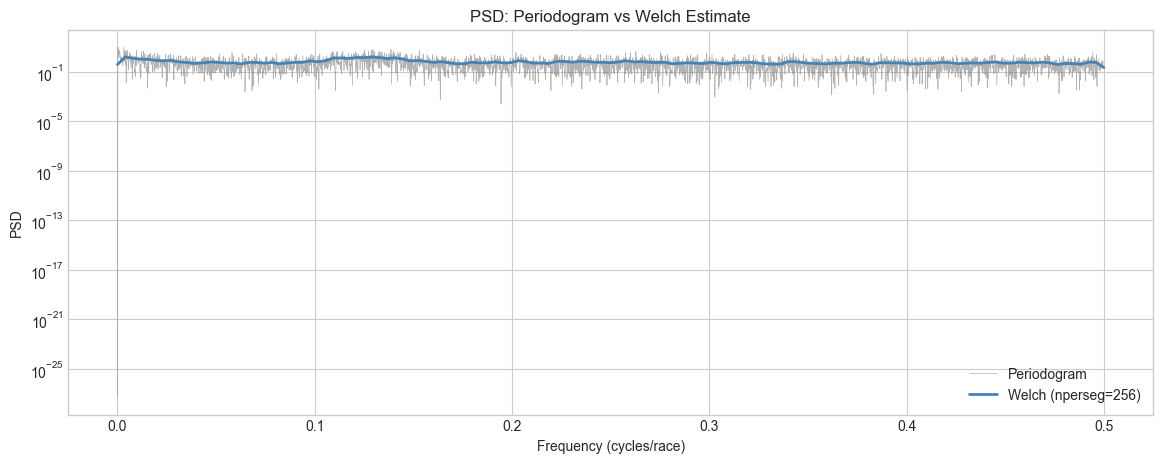

In [4]:
# Periodogram comparison
f_period, psd_period = sp_signal.periodogram(H, fs=1.0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.semilogy(f_period, psd_period, lw=0.5, alpha=0.6, color='gray', label='Periodogram')
f_w, psd_w = sp_signal.welch(H, fs=1.0, nperseg=256)
ax.semilogy(f_w, psd_w, lw=2, color='steelblue', label='Welch (nperseg=256)')
ax.set_xlabel('Frequency (cycles/race)')
ax.set_ylabel('PSD')
ax.set_title('PSD: Periodogram vs Welch Estimate')
ax.legend()
fig.savefig(FIG_DIR / 'unit2_periodogram_vs_welch.png', **SAVEKW)
plt.show()

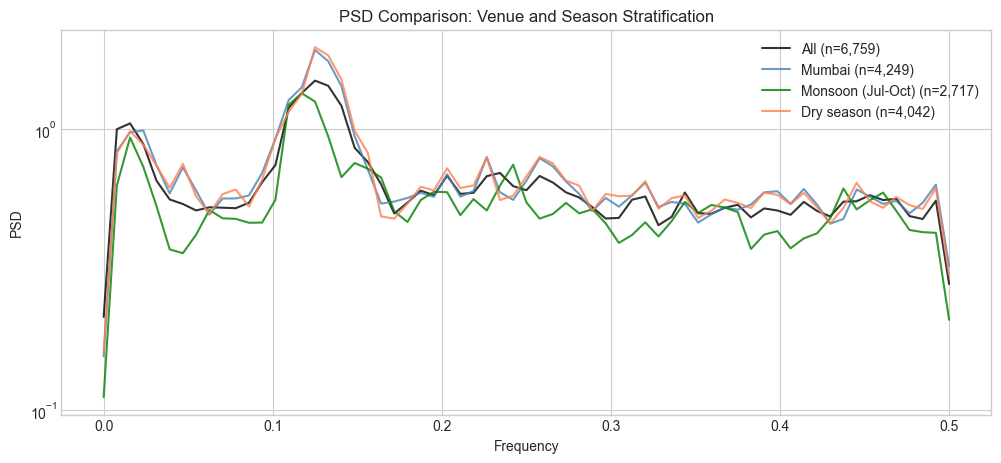

In [5]:
# Compare PSD: all venues, Mumbai only, monsoon vs dry
mumbai = df[df['venue'] == 'Mumbai']['entropy_H'].dropna().values
monsoon_months = [7, 8, 9, 10]
monsoon = df[df['meet_date'].dt.month.isin(monsoon_months)]['entropy_H'].dropna().values
dry = df[~df['meet_date'].dt.month.isin(monsoon_months)]['entropy_H'].dropna().values

fig, ax = plt.subplots(figsize=(12, 5))
for data, label, color in [(H, 'All', 'black'),
                            (mumbai, 'Mumbai', 'steelblue'),
                            (monsoon, 'Monsoon (Jul-Oct)', 'green'),
                            (dry, 'Dry season', 'coral')]:
    if len(data) > 128:
        f, p = sp_signal.welch(data, fs=1.0, nperseg=min(128, len(data) // 2))
        ax.semilogy(f, p, lw=1.5, label=f'{label} (n={len(data):,})', color=color, alpha=0.8)

ax.set_xlabel('Frequency')
ax.set_ylabel('PSD')
ax.set_title('PSD Comparison: Venue and Season Stratification')
ax.legend()
fig.savefig(FIG_DIR / 'unit2_psd_stratified.png', **SAVEKW)
plt.show()

## Section 3 — DFT Interpretation

In [6]:
# Parseval's theorem verification
energy_time = np.sum(H ** 2)
energy_freq = np.sum(np.abs(H_fft) ** 2) / N
print(f"Energy in time domain : {energy_time:.4f}")
print(f"Energy in freq domain : {energy_freq:.4f}")
print(f"Ratio (should be ≈1) : {energy_time / energy_freq:.6f}")

Energy in time domain : 51176.9609
Energy in freq domain : 51176.9609
Ratio (should be ≈1) : 1.000000


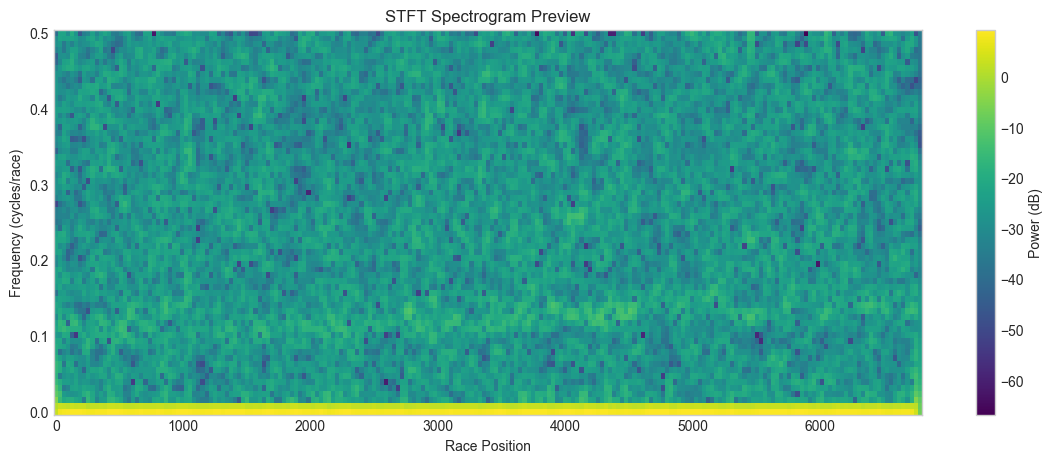

In [7]:
# Spectrogram preview (teaser for Unit 4)
fig, ax = plt.subplots(figsize=(14, 5))
f_stft, t_stft, Zxx = sp_signal.stft(H, fs=1.0, nperseg=128, noverlap=96)
ax.pcolormesh(t_stft, f_stft, 10 * np.log10(np.abs(Zxx) ** 2 + 1e-12),
              cmap='viridis', shading='auto')
ax.set_xlabel('Race Position')
ax.set_ylabel('Frequency (cycles/race)')
ax.set_title('STFT Spectrogram Preview')
fig.colorbar(ax.collections[0], ax=ax, label='Power (dB)')
fig.savefig(FIG_DIR / 'unit2_spectrogram_preview.png', **SAVEKW)
plt.show()

## Summary

- The FFT reveals dominant periodicities in the entropy signal.
- PSD analysis on a log-log scale tests for 1/f behaviour — a hallmark of long-range dependence.
- Welch's method provides a smoother PSD estimate than the raw periodogram.
- Seasonal and venue-based stratification reveals different spectral profiles.